email spam detection - svm
-----------------------------------
train accuracy: 0.812
test accuracy: 0.575
-----------------------------------
              precision    recall  f1-score   support

    not spam       0.60      0.78      0.68        23
        spam       0.50      0.29      0.37        17

    accuracy                           0.57        40
   macro avg       0.55      0.54      0.52        40
weighted avg       0.56      0.57      0.55        40



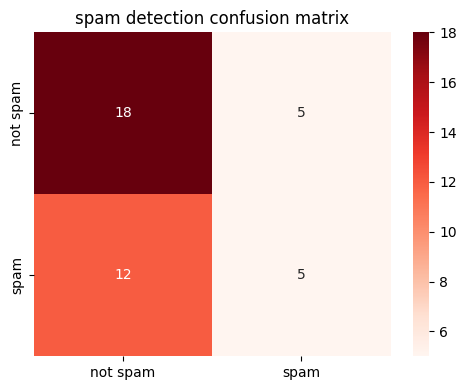

new email: not spam
confidence: 59.8 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200

data = {
    "word_count":      np.random.randint(10, 500, n),
    "links":           np.random.randint(0, 20, n),
    "exclamations":    np.random.randint(0, 10, n),
    "capitals_ratio":  np.random.uniform(0, 1, n),
    "has_attachment":  np.random.choice([0, 1], n),
    "is_spam":         np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

x = df.drop("is_spam", axis=1)
y = df["is_spam"]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

model = SVC(kernel="rbf", C=10, probability=True, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("email spam detection - svm")
print("-" * 35)
print("train accuracy:", round(model.score(x_train, y_train), 3))
print("test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("-" * 35)
print(classification_report(y_test, y_pred,
      target_names=["not spam", "spam"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["not spam", "spam"],
            yticklabels=["not spam", "spam"])
plt.title("spam detection confusion matrix")
plt.tight_layout()
plt.show()

# predict new email
new_email = scaler.transform([[150, 5, 3, 0.4, 1]])
result = model.predict(new_email)
prob = model.predict_proba(new_email)
print("new email:",
      "spam!" if result[0] == 1 else "not spam")
print("confidence:", round(max(prob[0]) * 100, 1), "%")